In [ ]:
!pip install xgboost

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

In [ ]:
df = pd.read_csv("/content/creditcard.csv")

print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())

Dataset Shape: (10000, 31)

First 5 Rows:
     Time        V1        V2        V3        V4        V5        V6  \
0  108940 -0.860524 -0.357004 -0.130059  0.277983  0.147613 -0.844999   
1   81788  0.677637 -0.265229 -0.433873  0.727275  0.546080  0.642449   
2   29680 -1.333148  0.686289  1.540429 -0.366756  1.070642  0.735865   
3   82844  0.026185  0.731111 -1.130804 -0.708213 -0.543628 -0.913548   
4   78929  1.333998  0.725492  1.355828  0.855544 -1.239781  1.896666   

         V7        V8        V9  ...       V21       V22       V23       V24  \
0 -0.457101  0.467611  1.806933  ...  0.662041 -0.138105 -2.523246  1.028723   
1  0.401573 -1.154611 -0.168301  ...  2.640061 -0.875368 -0.765684  0.665098   
2 -0.112057 -1.364201 -0.278549  ... -0.187524  0.027393 -0.041610  1.084260   
3 -1.845747 -0.244395 -1.159897  ...  0.898142  1.121685 -0.067025  1.420167   
4 -0.155655 -1.904351  0.347141  ... -0.604617  1.582253 -0.181744 -0.076977   

        V25       V26       V27       

In [ ]:
print("Class Distribution:")
print(df["Class"].value_counts())

# 0 = Genuine transaction
# 1 = Fraudulent transaction

Class Distribution:
Class
0    9800
1     200
Name: count, dtype: int64


In [ ]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (10000, 30)
Target Shape: (10000,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (8000, 30)
Testing Data: (2000, 30)


In [ ]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print("Negative Samples:", negative)
print("Positive Samples:", positive)
print("Scale Positive Weight:", scale_pos_weight)

Negative Samples: 7840
Positive Samples: 160
Scale Positive Weight: 49.0


In [ ]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1
)

print("XGBoost Model Created!")

XGBoost Model Created!


In [ ]:
model.fit(X_train, y_train)

print("Model Training Completed!")

Model Training Completed!


In [ ]:
y_prob = model.predict_proba(X_test)[:, 1]

# Threshold = 0.5
y_pred = (y_prob >= 0.5).astype(int)

print("Prediction Completed!")

Prediction Completed!


In [ ]:
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", round(roc_auc, 4))

ROC-AUC Score: 0.9999


In [ ]:
pr_auc = average_precision_score(y_test, y_prob)

print("PR-AUC Score:", round(pr_auc, 4))

PR-AUC Score: 0.9954


In [ ]:
print("Classification Report:")

print(classification_report(
    y_test,
    y_pred,
    target_names=["Genuine", "Fraud"]
))

Classification Report:
              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00      1960
       Fraud       0.97      0.95      0.96        40

    accuracy                           1.00      2000
   macro avg       0.99      0.97      0.98      2000
weighted avg       1.00      1.00      1.00      2000



Confusion Matrix:
[[1959    1]
 [   2   38]]


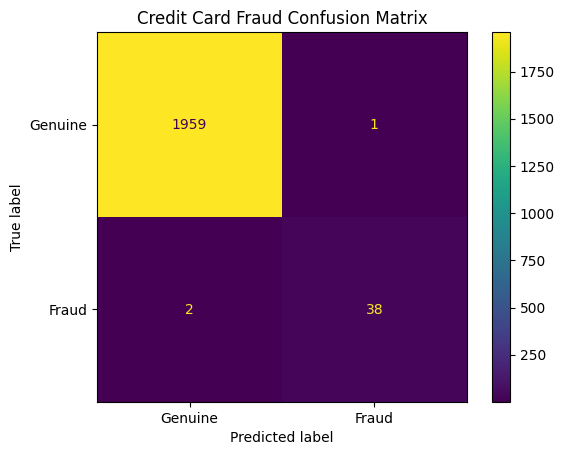

In [ ]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Genuine", "Fraud"]
)

disp.plot()

plt.title("Credit Card Fraud Confusion Matrix")
plt.show()

In [ ]:
tn, fp, fn, tp = cm.ravel()

print("Fraud Detection Analysis")

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

Fraud Detection Analysis
True Negatives: 1959
False Positives: 1
False Negatives: 2
True Positives: 38


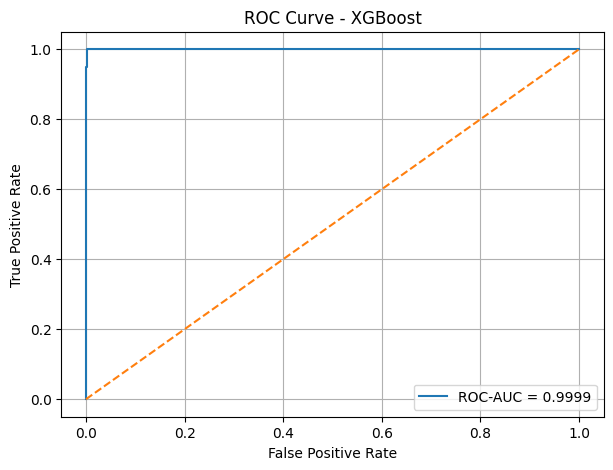

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - XGBoost")

plt.legend()
plt.grid()

plt.show()

In [ ]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(10)

print("Top 10 Important Features:")
print(importance)

Top 10 Important Features:
V1        0.462943
V14       0.192601
V3        0.142264
Time      0.056308
V8        0.036254
V4        0.016502
V16       0.014746
Amount    0.012617
V21       0.008317
V10       0.007975
dtype: float32


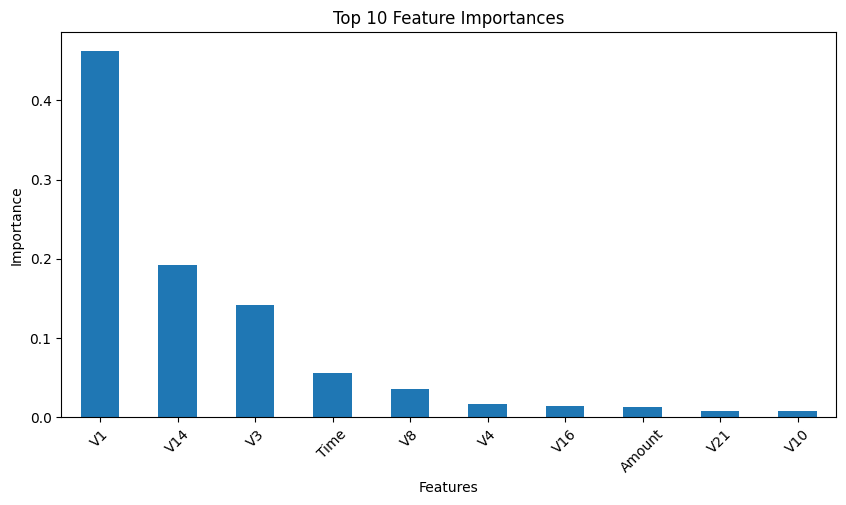

In [ ]:
importance.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Top 10 Feature Importances")
plt.ylabel("Importance")
plt.xlabel("Features")

plt.xticks(rotation=45)

plt.show()

In [ ]:
print("Conclusion:")
print("XGBoost was used for credit card fraud detection.")
print("Class imbalance was handled using scale_pos_weight.")
print("The model was evaluated using ROC-AUC and PR-AUC.")
print("False positives and false negatives were analyzed.")
print("Feature importance was also examined.")

Conclusion:
XGBoost was used for credit card fraud detection.
Class imbalance was handled using scale_pos_weight.
The model was evaluated using ROC-AUC and PR-AUC.
False positives and false negatives were analyzed.
Feature importance was also examined.
